<a href="https://colab.research.google.com/github/juanfran18gc-code/jfMIAAD/blob/02-Semana/Practica7_261554.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica #7 - Unidad 1. Análisis de un Dataset con Matplotlib
El objetivo de este ejercicio es que los estudiantes aprendan a cargar y explorar un dataset, y luego utilicen matplotlib para crear gráficos visuales que les permitan analizar e interpretar los datos.

Dataset:
Para este ejercicio, utilizaremos el famoso dataset Iris de la librería seaborn. Este dataset contiene información sobre diferentes especies de flores Iris y varias medidas de sus características (como el largo y ancho del sépalo y el pétalo).

Los estudiantes pueden cargarlo directamente desde la librería seaborn. Para ello emplea la siguiente instrucción:

df = sns.load_dataset('iris')

Instrucciones:
* Carga y exploración del dataset:

  * Cargar el dataset Iris utilizando seaborn o cualquier otro dataset de su elección.
  * Verificar las primeras filas del dataset con el método .head().
  * Obtener información general sobre los datos (nombres de columnas, tipos de datos, valores nulos, etc.).
* Crear los siguientes gráficos con Matplotlib:

  a) Gráfico de barras:

  * Objetivo: Comparar el promedio de largo y ancho de los pétalos entre las tres especies de Iris.
  * Instrucciones: Utiliza un gráfico de barras para mostrar la media de las columnas petal_length y petal_width agrupadas por species.
  
  b) Histograma:

  * Objetivo: Visualizar la distribución de los largos de los sépalos (sepal_length).
  * Instrucciones: Crea un histograma de la variable sepal_length y asegúrate de que tenga un número adecuado de bins. Coloca etiquetas en los ejes y un título.
  
  c) Gráfico de dispersión (scatter plot):

  * Objetivo: Relacionar el largo del pétalo con el ancho del pétalo.
  * Instrucciones: Crea un gráfico de dispersión que compare petal_length con petal_width. Usa un color diferente para cada especie.
  
  d) Gráfico de cajas (box plot):

  * Objetivo: Analizar la distribución de las medidas del sépalo (sepal_length, sepal_width).
  * Instrucciones: Crea un gráfico de cajas para mostrar la distribución de las variables sepal_length y sepal_width por especie.
  
  e) Gráfico de líneas:

  * Objetivo: Mostrar la tendencia de la longitud del pétalo (petal_length) a través de las observaciones.
  * Instrucciones: Crea un gráfico de líneas utilizando la variable petal_length (en el eje Y) con el índice de las observaciones (en el eje X). Puedes hacer esto para ver cómo varía la longitud del pétalo a lo largo del dataset.
* Formato y personalización de los gráficos:

  * Asegúrate de personalizar cada gráfico con títulos, etiquetas en los ejes, y leyendas cuando sea necesario.
  * Experimenta con diferentes colores, tamaños de figura y estilos de línea.

In [72]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Cargar el dataset Iris
dfiris= sns.load_dataset('iris')
#Imprimir las primeras y ultimas 5 filas
print(dfiris.head())
print(dfiris.tail())

#Obtener información general sobre los datos (nombres de columnas, tipos de datos, valores nulos, etc.).
print(dfiris.info())

#Descripción y estadisticas de valores numericas
print(f"\nResumen de las columnas numéricas:\n")
print(dfiris.describe())




   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
     sepal_length  sepal_width  petal_length  petal_width    species
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_l

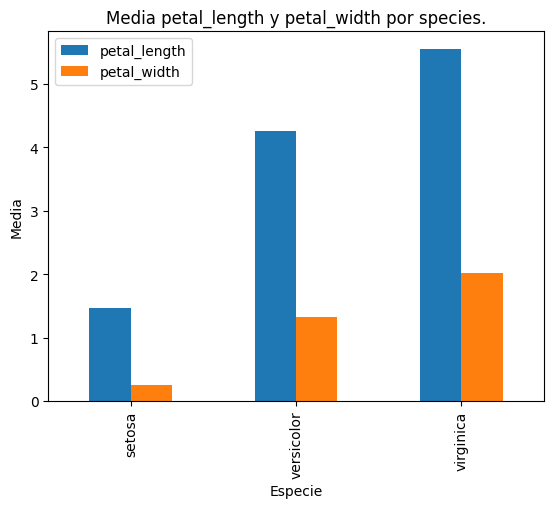

In [73]:
#a) Gráfico de barras
#Agrupar y calcular la media de petal_length y petal_width
promedio = dfiris.groupby('species')[['petal_length','petal_width']].mean()
#print(promedio)
promedio.plot(kind='bar')
plt.title('Media petal_length y petal_width por species.')
plt.xlabel('Especie')
plt.ylabel('Media')
plt.show()


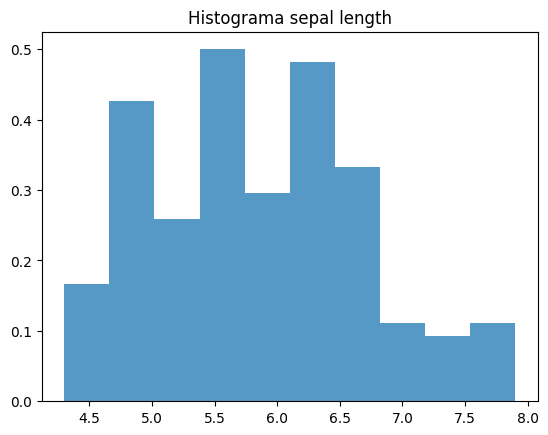

In [74]:
#Crear un histograma de la variable sepal_length
plt.hist(dfiris['sepal_length'], bins=10, density=True, facecolor='C0', alpha=0.75)
plt.title('Histograma sepal length')
plt.show()

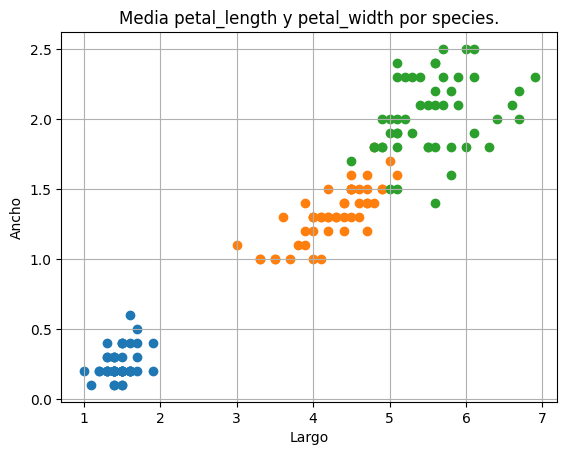

In [75]:
#Crear un gráfico de dispersión de petal_length vs petal_width. Usa un color diferente para cada especie.

for especie in dfiris['species'].unique():
    compara = dfiris[dfiris['species'] == especie]
    plt.scatter(compara['petal_length'], compara['petal_width'], label=especie)

plt.title('Media petal_length y petal_width por species.')
plt.xlabel('Largo')
plt.ylabel('Ancho')
plt.grid(True)
plt.show()

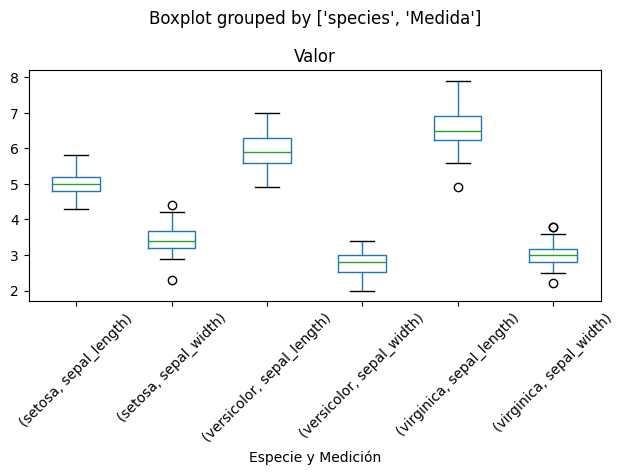

In [76]:
#Crear un gráfico de cajas de distribución de las variables sepal_length y sepal_width por especie
# Reorganizar los datos para graficar múltiples variables
irisnuevo = dfiris.melt(id_vars='species',
                        value_vars=['sepal_length', 'sepal_width'],
                        var_name='Medida',
                        value_name='Valor')

# Crear gráfico de cajas combinado
irisnuevo.boxplot(column='Valor', by=['species', 'Medida'], grid=False)
#plt.title('Distribución de Sepal Length y Sepal Width por Especie')
plt.xlabel('Especie y Medición')
#plt.ylabel('Valor')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

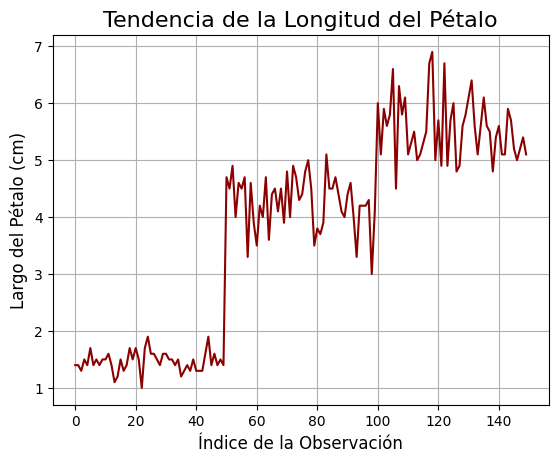

In [77]:
#Crear un gráfico de líneas con petal_length y con el índice de las observaciones
plt.plot(dfiris.index, dfiris['petal_length'], color='darkred')

# Añadir etiquetas y título
plt.title('Tendencia de la Longitud del Pétalo', fontsize=16)
plt.xlabel('Índice de la Observación', fontsize=12)
plt.ylabel('Largo del Pétalo (cm)', fontsize=12)
plt.grid(True) # Muestra una cuadrícula para una mejor referencia

# Mostrar el gráfico
plt.show()